In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
X_val = pd.read_csv("../data/processed/X_val.csv")
y_val = pd.read_csv("../data/processed/y_val.csv").squeeze()

/home/bahoore/projects/diabetes-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Threshold: 0.2 | Precision: 0.222 | Recall: 0.963 | F1: 0.361
Threshold: 0.3 | Precision: 0.261 | Recall: 0.917 | F1: 0.406
Threshold: 0.4 | Precision: 0.300 | Recall: 0.853 | F1: 0.443
Threshold: 0.5 | Precision: 0.339 | Recall: 0.761 | F1: 0.469
Threshold: 0.6 | Precision: 0.384 | Recall: 0.647 | F1: 0.482
Threshold: 0.7 | Precision: 0.438 | Recall: 0.490 | F1: 0.462
              precision    recall  f1-score   support

           0       0.96      0.63      0.76     32056
           1       0.30      0.85      0.44      5996

    accuracy                           0.66     38052
   macro avg       0.63      0.74      0.60     38052
weighted avg       0.85      0.66      0.71     38052



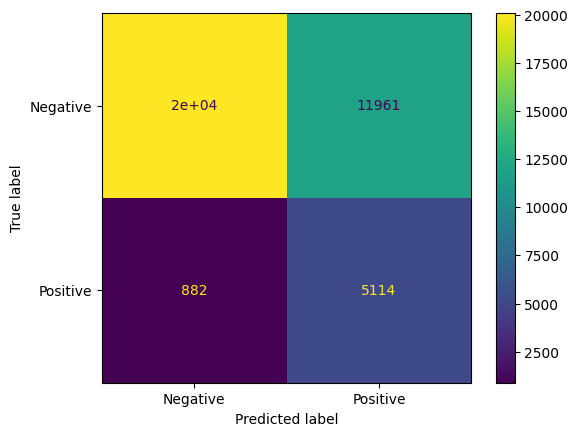

In [23]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

linear_pipeline.fit(
    X_train,
    y_train
)

y_prob = linear_pipeline.predict_proba(X_val)[:,1]

threshold = 0.4

y_pred = (y_prob >= threshold).astype(int)

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_pred_threshold)
    recall = recall_score(y_val, y_pred_threshold)
    f1 = f1_score(y_val, y_pred_threshold)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

# y_pred = linear_pipeline.predict(X_val)

print(
    classification_report(
        y_val,
        y_pred
    )
)

roc_auc_score(
    y_val,
    y_prob
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
    display_labels=["Negative", "Positive"]
)

plt.show()